In [1]:
# ============================================================
# HumanEval Best-of-N Proxy Migration + Pass@1 Execution Analysis
# Cached / production-ready version
# Selectors: Skywork-RM vs FsfairX-RM
#
# Outputs:
#   - humaneval_execution_cache.parquet
#   - humaneval_full_execution_results.csv
#   - humaneval_divergence_summary.csv
#   - humaneval_goodhart_execution_curve.png
# ============================================================

# =========================
# Cell 1: Imports
# =========================
import os
import io
import re
import ast
import json
import math
import time
import signal
import traceback
import warnings
import contextlib
from pathlib import Path
import concurrent.futures as cf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

In [2]:
# =========================
# Cell 2: Paths / Config
# =========================
POOL_PATH = Path("/kaggle/input/notebooks/mrsstrange012/llama-humaneval-pool/humaneval_pool_llama31_8b_vllm.jsonl")
SKYWORK_PATH = Path("/kaggle/input/notebooks/mrsstrange012/humaneval-skywork-score/skywork_humaneval_scored.csv")
FSFAIRX_PATH = Path("/kaggle/input/notebooks/mrsstrange012/humaneval-fsfairx-score/fsfairx_humaneval_scored.csv")

EXEC_CACHE_PATH = Path("humaneval_execution_cache.parquet")
OUT_FULL = Path("humaneval_full_execution_results.csv")
OUT_DIV = Path("humaneval_divergence_summary.csv")
OUT_PLOT = Path("humaneval_goodhart_execution_curve.png")

N_LIST = [1, 2, 4, 8, 16, 32, 64, 128, 256]
EXEC_TIMEOUT_SEC = 3.0
MAX_WORKERS = min(8, max(1, (os.cpu_count() or 2) - 1))
EXEC_CHUNKSIZE = 64

print("POOL_PATH exists:", POOL_PATH.exists())
print("SKYWORK_PATH exists:", SKYWORK_PATH.exists())
print("FSFAIRX_PATH exists:", FSFAIRX_PATH.exists())
print("MAX_WORKERS:", MAX_WORKERS)

POOL_PATH exists: True
SKYWORK_PATH exists: True
FSFAIRX_PATH exists: True
MAX_WORKERS: 3


In [3]:
# =========================
# Cell 3: Schema helpers
# =========================
def standardize_task_id(x):
    if pd.isna(x):
        return None
    return str(x).strip()

def standardize_cand_idx(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    if "candidx" in df.columns and "cand_idx" not in df.columns:
        rename_map["candidx"] = "cand_idx"
    df = df.rename(columns=rename_map)
    if "cand_idx" not in df.columns:
        raise ValueError(f"Missing cand_idx/candidx column. Found: {df.columns.tolist()}")
    df["cand_idx"] = df["cand_idx"].astype(int)
    return df

def standardize_reward_cols(df: pd.DataFrame, rm_name: str) -> pd.DataFrame:
    df = df.copy()

    if rm_name == "skywork":
        if "skywork_raw" not in df.columns and "score" in df.columns:
            df = df.rename(columns={"score": "skywork_raw"})
        if "skywork_raw" not in df.columns:
            raise ValueError("Skywork score column missing. Expected skywork_raw or score.")

    elif rm_name == "fsfairx":
        if "fsfairx_raw" not in df.columns and "score" in df.columns:
            df = df.rename(columns={"score": "fsfairx_raw"})
        if "fsfairx_raw" not in df.columns:
            raise ValueError("FsfairX score column missing. Expected fsfairx_raw or score.")

    return df

In [4]:
# =========================
# Cell 4: Load HumanEval pool JSONL
# =========================
pool_rows = []

with open(POOL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)

        task_id = standardize_task_id(rec["task_id"])
        prompt = rec["prompt"]
        entry_point = rec["entry_point"]
        canonical_solution = rec.get("canonical_solution", "")
        test_str = rec["test"]
        candidates = rec["candidates"]

        for cand_idx, cand_text in enumerate(candidates):
            pool_rows.append({
                "task_id": task_id,
                "cand_idx": int(cand_idx),
                "prompt": prompt,
                "entry_point": entry_point,
                "canonical_solution": canonical_solution,
                "test": test_str,
                "candidate_text": cand_text,
            })

pool_df = pd.DataFrame(pool_rows)

print("Pool shape:", pool_df.shape)
print("Unique tasks:", pool_df["task_id"].nunique())
print("Candidates per task summary:")
print(pool_df.groupby("task_id").size().describe())

Pool shape: (41984, 7)
Unique tasks: 164
Candidates per task summary:
count    164.0
mean     256.0
std        0.0
min      256.0
25%      256.0
50%      256.0
75%      256.0
max      256.0
dtype: float64


In [5]:
# =========================
# Cell 5: Load score files
# =========================
sky_df = pd.read_csv(SKYWORK_PATH)
fs_df = pd.read_csv(FSFAIRX_PATH)

print("Raw Skywork columns:", sky_df.columns.tolist())
print("Raw FsfairX columns:", fs_df.columns.tolist())

Raw Skywork columns: ['task_id', 'cand_idx', 'skywork_raw', 'prompt', 'text', 'entry_point', 'canonical_solution', 'test']
Raw FsfairX columns: ['task_id', 'cand_idx', 'fsfairx_raw', 'prompt', 'text', 'entry_point', 'canonical_solution', 'test']


In [6]:
# =========================
# Cell 6: Standardize score schemas
# =========================
sky_df["task_id"] = sky_df["task_id"].map(standardize_task_id)
fs_df["task_id"] = fs_df["task_id"].map(standardize_task_id)

sky_df = standardize_cand_idx(sky_df)
fs_df = standardize_cand_idx(fs_df)

sky_df = standardize_reward_cols(sky_df, "skywork")
fs_df = standardize_reward_cols(fs_df, "fsfairx")

sky_df = sky_df[["task_id", "cand_idx", "skywork_raw"]].copy()
fs_df = fs_df[["task_id", "cand_idx", "fsfairx_raw"]].copy()

print("Standardized Skywork shape:", sky_df.shape)
print("Standardized FsfairX shape:", fs_df.shape)

Standardized Skywork shape: (41984, 3)
Standardized FsfairX shape: (41984, 3)


In [7]:
# =========================
# Cell 7: Merge pool + RM scores
# =========================
df = (
    pool_df
    .merge(sky_df, on=["task_id", "cand_idx"], how="left")
    .merge(fs_df, on=["task_id", "cand_idx"], how="left")
)

print("Merged shape:", df.shape)
print(df.head(3))
print("\nMissing fraction:")
print(df[["skywork_raw", "fsfairx_raw"]].isna().mean())

Merged shape: (41984, 9)
       task_id  cand_idx                                             prompt         entry_point                                 canonical_solution                                               test  \
0  HumanEval/0         0  from typing import List\n\n\ndef has_close_ele...  has_close_elements      for idx, elem in enumerate(numbers):\n    ...  \n\nMETADATA = {\n    'author': 'jt',\n    'da...   
1  HumanEval/0         1  from typing import List\n\n\ndef has_close_ele...  has_close_elements      for idx, elem in enumerate(numbers):\n    ...  \n\nMETADATA = {\n    'author': 'jt',\n    'da...   
2  HumanEval/0         2  from typing import List\n\n\ndef has_close_ele...  has_close_elements      for idx, elem in enumerate(numbers):\n    ...  \n\nMETADATA = {\n    'author': 'jt',\n    'da...   

                                      candidate_text  skywork_raw  fsfairx_raw  
0  from typing import List\n\ndef has_close_eleme...    24.569305     0.914675  
1  from 

In [8]:
# =========================
# Cell 8: AST / structural metrics
# =========================
BRANCH_TYPES = (ast.If, ast.For, ast.While, ast.Try, ast.AsyncFor, ast.IfExp)

def code_word_count(text: str) -> int:
    if pd.isna(text) or not str(text).strip():
        return 0
    return len(re.findall(r"\S+", str(text)))

def nonempty_line_count(text: str) -> int:
    if pd.isna(text) or not str(text):
        return 0
    lines = [ln for ln in str(text).splitlines() if ln.strip()]
    return max(len(lines), 1)

def extract_ast_metrics(code: str):
    out = {
        "code_word_count": 0,
        "ast_node_count": 0,
        "branching_density": 0.0,
        "helper_fn_count": 0,
        "ast_parse_ok": 0,
    }

    if pd.isna(code) or not str(code).strip():
        return out

    code = str(code)
    out["code_word_count"] = code_word_count(code)

    try:
        tree = ast.parse(code)
        nodes = list(ast.walk(tree))
        out["ast_node_count"] = len(nodes)
        out["helper_fn_count"] = sum(isinstance(n, ast.FunctionDef) for n in nodes)
        branch_count = sum(isinstance(n, BRANCH_TYPES) for n in nodes)
        out["branching_density"] = branch_count / max(nonempty_line_count(code), 1)
        out["ast_parse_ok"] = 1
    except Exception:
        pass

    return out

ast_metrics = df["candidate_text"].apply(extract_ast_metrics).apply(pd.Series)
df = pd.concat([df, ast_metrics], axis=1)

print(df[["code_word_count", "ast_node_count", "branching_density", "helper_fn_count", "ast_parse_ok"]].describe())

       code_word_count  ast_node_count  branching_density  helper_fn_count  ast_parse_ok
count     41984.000000    41984.000000       41984.000000     41984.000000  41984.000000
mean         30.693431       59.767959           0.180716         1.108994      0.986233
std          20.486276       36.212249           0.187548         0.373070      0.116524
min           4.000000        0.000000           0.000000         0.000000      0.000000
25%          16.000000       35.000000           0.000000         1.000000      1.000000
50%          27.000000       55.000000           0.200000         1.000000      1.000000
75%          40.000000       77.000000           0.307692         1.000000      1.000000
max         161.000000      345.000000           6.000000         5.000000      1.000000


In [9]:
# =========================
# Cell 9: Execution harness
# =========================
class ExecTimeoutError(Exception):
    pass

def _alarm_handler(signum, frame):
    raise ExecTimeoutError("Execution timed out")

def build_execution_script(candidate_text: str, test_str: str, entry_point: str) -> str:
    return "\n".join([
        str(candidate_text).rstrip(),
        "",
        str(test_str).rstrip(),
        "",
        f"check({entry_point})",
        ""
    ])

def execute_candidate(payload):
    """
    Runs one candidate inside one worker process.
    Timeout is enforced inside the worker using SIGALRM.
    Linux/Kaggle-friendly.
    """
    row_idx, task_id, cand_idx, candidate_text, test_str, entry_point, timeout_sec = payload
    code = build_execution_script(candidate_text, test_str, entry_point)

    old_handler = signal.signal(signal.SIGALRM, _alarm_handler)
    signal.setitimer(signal.ITIMER_REAL, timeout_sec)

    try:
        sandbox_globals = {"__name__": "__main__"}

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            exec(code, sandbox_globals, sandbox_globals)

        return {
            "row_idx": row_idx,
            "task_id": task_id,
            "cand_idx": cand_idx,
            "passed": 1,
            "exec_status": "passed",
            "error_type": None,
            "error_msg": None,
        }

    except ExecTimeoutError as e:
        return {
            "row_idx": row_idx,
            "task_id": task_id,
            "cand_idx": cand_idx,
            "passed": 0,
            "exec_status": "timeout",
            "error_type": "Timeout",
            "error_msg": str(e)[:500],
        }

    except SyntaxError as e:
        return {
            "row_idx": row_idx,
            "task_id": task_id,
            "cand_idx": cand_idx,
            "passed": 0,
            "exec_status": "failed",
            "error_type": "SyntaxError",
            "error_msg": "".join(traceback.format_exception_only(type(e), e)).strip()[:500],
        }

    except AssertionError as e:
        return {
            "row_idx": row_idx,
            "task_id": task_id,
            "cand_idx": cand_idx,
            "passed": 0,
            "exec_status": "failed",
            "error_type": "AssertionError",
            "error_msg": "".join(traceback.format_exception_only(type(e), e)).strip()[:500],
        }

    except Exception as e:
        return {
            "row_idx": row_idx,
            "task_id": task_id,
            "cand_idx": cand_idx,
            "passed": 0,
            "exec_status": "failed",
            "error_type": type(e).__name__,
            "error_msg": "".join(traceback.format_exception_only(type(e), e)).strip()[:500],
        }

    finally:
        signal.setitimer(signal.ITIMER_REAL, 0)
        signal.signal(signal.SIGALRM, old_handler)

In [10]:
# =========================
# Cell 10: Cached execution pass
# =========================
def evaluate_all_candidates_parallel(in_df: pd.DataFrame,
                                     timeout_sec: float = 3.0,
                                     nproc: int = 8,
                                     chunksize: int = 64,
                                     cache_path: Path = EXEC_CACHE_PATH) -> pd.DataFrame:
    """
    Stage 1:
      - If cache exists, reuse it.
      - Otherwise execute all candidates once, cache results to parquet.
    """
    work_df = in_df.copy()

    if cache_path.exists():
        print(f"Loading existing execution cache from {cache_path} ...")
        cache_df = pd.read_parquet(cache_path)
        out = work_df.merge(cache_df, on=["task_id", "cand_idx"], how="left")
        out["passed"] = out["passed"].fillna(0).astype(int)
        out["exec_status"] = out["exec_status"].fillna("failed")
        return out

    payloads = [
        (
            idx,
            row["task_id"],
            int(row["cand_idx"]),
            row["candidate_text"],
            row["test"],
            row["entry_point"],
            timeout_sec,
        )
        for idx, row in work_df.iterrows()
    ]

    print(f"Running execution checks with nproc={nproc}, timeout={timeout_sec:.1f}s, chunksize={chunksize} ...")
    print(f"Total candidates: {len(payloads)}")

    results = []
    start = time.time()

    with cf.ProcessPoolExecutor(max_workers=nproc) as ex:
        for i, res in enumerate(ex.map(execute_candidate, payloads, chunksize=chunksize), start=1):
            results.append(res)

            if i % 1000 == 0 or i == len(payloads):
                elapsed = time.time() - start
                rate = i / max(elapsed, 1e-9)
                remaining = (len(payloads) - i) / max(rate, 1e-9)
                print(f"Processed {i}/{len(payloads)} | elapsed={elapsed/60:.1f} min | rate={rate:.2f}/s | ETA={remaining/60:.1f} min")

    res_df = pd.DataFrame(results).sort_values("row_idx").reset_index(drop=True)

    cache_df = res_df[["task_id", "cand_idx", "passed", "exec_status", "error_type", "error_msg"]].copy()
    cache_df.to_parquet(cache_path, index=False)
    print(f"Saved execution cache to {cache_path.resolve()}")

    res_df = res_df.set_index("row_idx")
    work_df = work_df.join(res_df[["passed", "exec_status", "error_type", "error_msg"]], how="left")
    work_df["passed"] = work_df["passed"].fillna(0).astype(int)
    work_df["exec_status"] = work_df["exec_status"].fillna("failed")

    return work_df

In [11]:
# =========================
# Cell 11: Execute all candidates once
# =========================
df = evaluate_all_candidates_parallel(
    df,
    timeout_sec=EXEC_TIMEOUT_SEC,
    nproc=MAX_WORKERS,
    chunksize=EXEC_CHUNKSIZE,
    cache_path=EXEC_CACHE_PATH
)

print("\nExecution status breakdown:")
print(df["exec_status"].value_counts(dropna=False))
print("\nPool-level pass fraction:", round(100 * df["passed"].mean(), 3), "%")

Running execution checks with nproc=3, timeout=3.0s, chunksize=64 ...
Total candidates: 41984
Processed 1000/41984 | elapsed=0.0 min | rate=4195.13/s | ETA=0.2 min
Processed 2000/41984 | elapsed=0.0 min | rate=5410.10/s | ETA=0.1 min
Processed 3000/41984 | elapsed=0.2 min | rate=316.19/s | ETA=2.1 min
Processed 4000/41984 | elapsed=0.2 min | rate=421.56/s | ETA=1.5 min
Processed 5000/41984 | elapsed=0.4 min | rate=232.06/s | ETA=2.7 min
Processed 6000/41984 | elapsed=0.4 min | rate=278.46/s | ETA=2.2 min
Processed 7000/41984 | elapsed=0.4 min | rate=324.86/s | ETA=1.8 min
Processed 8000/41984 | elapsed=0.4 min | rate=371.26/s | ETA=1.5 min
Processed 9000/41984 | elapsed=0.6 min | rate=251.35/s | ETA=2.2 min
Processed 10000/41984 | elapsed=1.4 min | rate=121.95/s | ETA=4.4 min
Processed 11000/41984 | elapsed=1.8 min | rate=103.68/s | ETA=5.0 min
Processed 12000/41984 | elapsed=1.8 min | rate=113.10/s | ETA=4.4 min
Processed 13000/41984 | elapsed=1.8 min | rate=122.53/s | ETA=3.9 min
Pro

In [12]:
# =========================
# Cell 12: Selection sweep
# =========================
def safe_mean(series):
    if len(series) == 0:
        return np.nan
    return float(np.mean(series))

def evaluate_selector(full_df: pd.DataFrame, selector_col: str, selector_name: str, n_list):
    rows = []
    cross_col = "fsfairx_raw" if selector_col == "skywork_raw" else "skywork_raw"

    for N in n_list:
        selected_rows = []

        for task_id, g in full_df.groupby("task_id", sort=True):
            g = g.sort_values("cand_idx").copy()
            topn = g.iloc[:min(len(g), N)].copy()

            valid = topn[topn[selector_col].notna()].copy()
            if len(valid) == 0:
                continue

            valid = valid.sort_values(by=[selector_col, "cand_idx"], ascending=[False, True])
            best = valid.iloc[0]
            selected_rows.append(best)

        sel = pd.DataFrame(selected_rows).reset_index(drop=True)

        rows.append({
            "selector": selector_name,
            "N": int(N),
            "num_tasks_used": int(sel["task_id"].nunique()),
            "selector_score_mean": safe_mean(sel[selector_col]),
            "cross_rm_score_mean": safe_mean(sel[cross_col]),
            "pass_at_1": safe_mean(sel["passed"]),
            "pass_at_1_pct": 100.0 * safe_mean(sel["passed"]),
            "avg_code_word_count": safe_mean(sel["code_word_count"]),
            "avg_ast_node_count": safe_mean(sel["ast_node_count"]),
            "avg_branching_density": safe_mean(sel["branching_density"]),
            "avg_helper_fn_count": safe_mean(sel["helper_fn_count"]),
            "avg_skywork_raw": safe_mean(sel["skywork_raw"]),
            "avg_fsfairx_raw": safe_mean(sel["fsfairx_raw"]),
        })

    return pd.DataFrame(rows).sort_values(["selector", "N"]).reset_index(drop=True)

sky_results = evaluate_selector(df, "skywork_raw", "SkyworkRM", N_LIST)
fs_results = evaluate_selector(df, "fsfairx_raw", "FsfairXRM", N_LIST)
results = pd.concat([sky_results, fs_results], ignore_index=True)

results

,selector,N,num_tasks_used,selector_score_mean,cross_rm_score_mean,pass_at_1,pass_at_1_pct,avg_code_word_count,avg_ast_node_count,avg_branching_density,avg_helper_fn_count,avg_skywork_raw,avg_fsfairx_raw
0,SkyworkRM,1,164,14.477765,-0.469926,0.567073,56.707317,30.628049,60.250000,0.216580,1.085366,14.477765,-0.469926
1,SkyworkRM,2,164,17.063711,-0.111485,0.621951,62.195122,30.652439,58.871951,0.226055,1.115854,17.063711,-0.111485
2,SkyworkRM,4,164,18.634783,0.010323,0.621951,62.195122,30.408537,59.451220,0.177541,1.121951,18.634783,0.010323
3,SkyworkRM,8,164,19.782904,0.103138,0.640244,64.024390,29.890244,59.518293,0.175700,1.121951,19.782904,0.103138
4,SkyworkRM,16,164,20.719234,0.114299,0.621951,62.195122,29.262195,56.847561,0.163968,1.103659,20.719234,0.114299
5,SkyworkRM,32,164,21.364114,0.225053,0.664634,66.463415,29.036585,58.664634,0.166317,1.121951,21.364114,0.225053
6,SkyworkRM,64,164,21.753185,0.254172,0.652439,65.243902,28.670732,56.841463,0.157591,1.134146,21.753185,0.254172
7,SkyworkRM,128,164,22.093880,0.319917,0.670732,67.073171,29.469512,58.030488,0.160965,1.134146,22.093880,0.319917
8,SkyworkRM,256,164,22.457598,0.317325,0.664634,66.463415,29.859756,57.939024,0.164229,1.140244,22.457598,0.317325
9,FsfairXRM,1,164,-0.469926,14.477765,0.567073,56.707317,30.628049,60.250000,0.216580,1.085366,14.477765,-0.469926


In [13]:
# =========================
# Cell 13: Divergence / over-optimization summary
# =========================
def summarize_divergence(res_df: pd.DataFrame, selector_name: str):
    d = res_df[res_df["selector"] == selector_name].sort_values("N").reset_index(drop=True)

    if len(d) < 2:
        return {
            "selector": selector_name,
            "selector_gain_n1_to_n256": np.nan,
            "cross_evaluator_gain_n1_to_n256": np.nan,
            "pass_at_1_delta_n1_to_n256": np.nan,
            "over_optimization_observed": "Insufficient data",
            "reason": "Need at least two N points."
        }

    first = d.iloc[0]
    last = d.iloc[-1]

    selector_gain = float(last["selector_score_mean"] - first["selector_score_mean"])
    cross_gain = float(last["cross_rm_score_mean"] - first["cross_rm_score_mean"])
    pass_delta = float(last["pass_at_1_pct"] - first["pass_at_1_pct"])

    pass_peak = float(d["pass_at_1_pct"].max())
    final_pass = float(last["pass_at_1_pct"])

    plateau_or_drop = (pass_delta <= 0.0) or (final_pass < pass_peak)
    overopt = (selector_gain > 0.0) and plateau_or_drop

    return {
        "selector": selector_name,
        "selector_gain_n1_to_n256": round(selector_gain, 6),
        "cross_evaluator_gain_n1_to_n256": round(cross_gain, 6),
        "pass_at_1_delta_n1_to_n256": round(pass_delta, 6),
        "over_optimization_observed": "Yes" if overopt else "No",
        "reason": (
            f"selector_gain={selector_gain:.6f}; "
            f"cross_gain={cross_gain:.6f}; "
            f"pass_delta={pass_delta:.4f}; "
            f"pass_peak={pass_peak:.4f}; "
            f"final_pass={final_pass:.4f}"
        )
    }

divergence_df = pd.DataFrame([
    summarize_divergence(results, "SkyworkRM"),
    summarize_divergence(results, "FsfairXRM"),
])

divergence_df

,selector,selector_gain_n1_to_n256,cross_evaluator_gain_n1_to_n256,pass_at_1_delta_n1_to_n256,over_optimization_observed,reason
0,SkyworkRM,7.979833,0.787250,9.756098,Yes,selector_gain=7.979833; cross_gain=0.787250; p...
1,FsfairXRM,1.345300,4.116605,11.585366,Yes,selector_gain=1.345300; cross_gain=4.116605; p...


In [14]:
# =========================
# Cell 14: Clean markdown summary tables
# =========================
sky_show = sky_results[[
    "N",
    "selector_score_mean",
    "cross_rm_score_mean",
    "pass_at_1_pct",
    "avg_code_word_count",
    "avg_ast_node_count",
    "avg_branching_density",
    "avg_helper_fn_count",
]].copy()

sky_show.columns = [
    "N",
    "Skywork_sel_score",
    "FsfairX_cross_score",
    "Pass@1_pct",
    "Avg_code_words",
    "Avg_AST_nodes",
    "Avg_branch_density",
    "Avg_helper_fns",
]

fs_show = fs_results[[
    "N",
    "selector_score_mean",
    "cross_rm_score_mean",
    "pass_at_1_pct",
    "avg_code_word_count",
    "avg_ast_node_count",
    "avg_branching_density",
    "avg_helper_fn_count",
]].copy()

fs_show.columns = [
    "N",
    "FsfairX_sel_score",
    "Skywork_cross_score",
    "Pass@1_pct",
    "Avg_code_words",
    "Avg_AST_nodes",
    "Avg_branch_density",
    "Avg_helper_fns",
]

sky_print = sky_show.copy()
fs_print = fs_show.copy()

for c in sky_print.columns:
    if c != "N":
        sky_print[c] = sky_print[c].astype(float).round(4)

for c in fs_print.columns:
    if c != "N":
        fs_print[c] = fs_print[c].astype(float).round(4)

print("\n# HumanEval Best-of-N Summary: Skywork Selection\n")
print(sky_print.to_markdown(index=False))

print("\n# HumanEval Best-of-N Summary: FsfairX Selection\n")
print(fs_print.to_markdown(index=False))

print("\n# Divergence Summary\n")
print(divergence_df.to_markdown(index=False))


# HumanEval Best-of-N Summary: Skywork Selection

|   N |   Skywork_sel_score |   FsfairX_cross_score |   Pass@1_pct |   Avg_code_words |   Avg_AST_nodes |   Avg_branch_density |   Avg_helper_fns |
|----:|--------------------:|----------------------:|-------------:|-----------------:|----------------:|---------------------:|-----------------:|
|   1 |             14.4778 |               -0.4699 |      56.7073 |          30.628  |         60.25   |               0.2166 |           1.0854 |
|   2 |             17.0637 |               -0.1115 |      62.1951 |          30.6524 |         58.872  |               0.2261 |           1.1159 |
|   4 |             18.6348 |                0.0103 |      62.1951 |          30.4085 |         59.4512 |               0.1775 |           1.122  |
|   8 |             19.7829 |                0.1031 |      64.0244 |          29.8902 |         59.5183 |               0.1757 |           1.122  |
|  16 |             20.7192 |                0.1143 |      62

In [15]:
# =========================
# Cell 15: Save CSV outputs
# =========================
df.to_csv(OUT_FULL, index=False)
divergence_df.to_csv(OUT_DIV, index=False)

print("Saved full results to:", OUT_FULL.resolve())
print("Saved divergence summary to:", OUT_DIV.resolve())
print("Execution cache at:", EXEC_CACHE_PATH.resolve())

Saved full results to: /kaggle/working/humaneval_full_execution_results.csv
Saved divergence summary to: /kaggle/working/humaneval_divergence_summary.csv
Execution cache at: /kaggle/working/humaneval_execution_cache.parquet


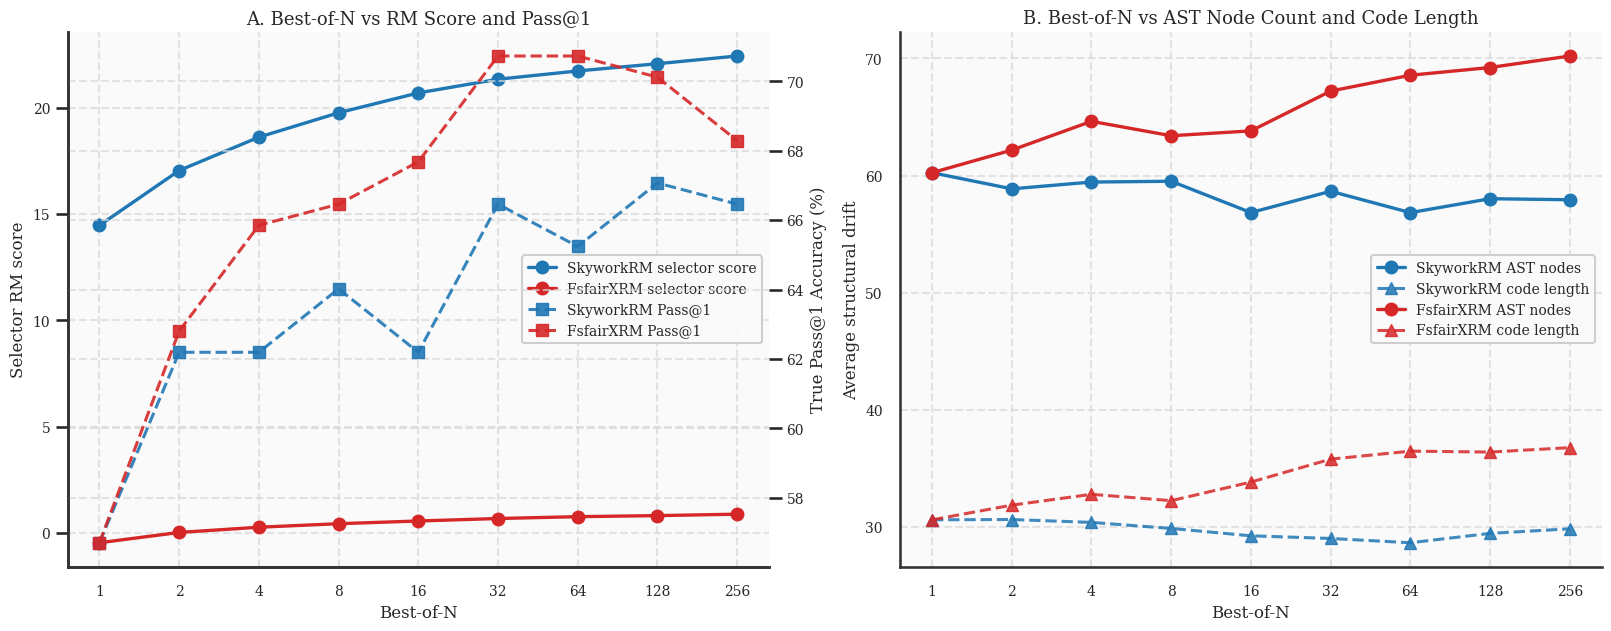

Saved plot to: /kaggle/working/humaneval_goodhart_execution_curve.png


In [16]:
# =========================
# Cell 16: Publication-quality 2-panel figure
# =========================
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#d9d9d9",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.dpi": 300,
})

palette = {
    "SkyworkRM": "#1f77b4",
    "FsfairXRM": "#d62728",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), constrained_layout=True)

# Panel A
ax1 = axes[0]
ax1b = ax1.twinx()

for selector in ["SkyworkRM", "FsfairXRM"]:
    d = results[results["selector"] == selector].sort_values("N")

    ax1.plot(
        d["N"], d["selector_score_mean"],
        color=palette[selector], marker="o", linewidth=2.4,
        label=f"{selector} selector score"
    )
    ax1b.plot(
        d["N"], d["pass_at_1_pct"],
        color=palette[selector], marker="s", linestyle="--", linewidth=2.2, alpha=0.9,
        label=f"{selector} Pass@1"
    )

ax1.set_xscale("log", base=2)
ax1.set_xticks(N_LIST)
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax1.set_xlabel("Best-of-N")
ax1.set_ylabel("Selector RM score")
ax1b.set_ylabel("True Pass@1 Accuracy (%)")
ax1.set_title("A. Best-of-N vs RM Score and Pass@1")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", framealpha=0.95)

# Panel B
ax2 = axes[1]

for selector in ["SkyworkRM", "FsfairXRM"]:
    d = results[results["selector"] == selector].sort_values("N")

    ax2.plot(
        d["N"], d["avg_ast_node_count"],
        color=palette[selector], marker="o", linewidth=2.4,
        label=f"{selector} AST nodes"
    )
    ax2.plot(
        d["N"], d["avg_code_word_count"],
        color=palette[selector], marker="^", linestyle="--", linewidth=2.2, alpha=0.85,
        label=f"{selector} code length"
    )

ax2.set_xscale("log", base=2)
ax2.set_xticks(N_LIST)
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel("Best-of-N")
ax2.set_ylabel("Average structural drift")
ax2.set_title("B. Best-of-N vs AST Node Count and Code Length")
ax2.legend(loc="best", framealpha=0.95)

plt.savefig(OUT_PLOT, bbox_inches="tight")
plt.show()

print("Saved plot to:", OUT_PLOT.resolve())

In [17]:
# =========================
# Cell 17: Final compact verdict
# =========================
print("\n=== Over-Optimization Verdict ===")
for _, row in divergence_df.iterrows():
    print(f"{row['selector']}: Over-Optimization Observed = {row['over_optimization_observed']}")
    print(f"Reason: {row['reason']}")
    print("-" * 100)


=== Over-Optimization Verdict ===
SkyworkRM: Over-Optimization Observed = Yes
Reason: selector_gain=7.979833; cross_gain=0.787250; pass_delta=9.7561; pass_peak=67.0732; final_pass=66.4634
----------------------------------------------------------------------------------------------------
FsfairXRM: Over-Optimization Observed = Yes
Reason: selector_gain=1.345300; cross_gain=4.116605; pass_delta=11.5854; pass_peak=70.7317; final_pass=68.2927
----------------------------------------------------------------------------------------------------
